# SuperMarket Sales Analysis

## Project Overview
This project analyzes supermarket sales data to identify meaningful patterns in sales,
customer behavior, product performance, payment methods, and branch performance.

The analysis uses Python, Pandas, NumPy, Matplotlib, and Seaborn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("SuperMarket Analysis.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [5]:
df.tail()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1
999,849-09-3807,Alex,Yangon,Member,Female,Fashion accessories,88.34,7,30.9190,649.2990,2/18/2019,1:28:00 PM,Cash,618.38,4.761905,30.9190,6.6


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1000
Number of columns: 17


## Dataset Information

The dataset contains 1,000 supermarket transactions and 17 variables.
These variables describe customer information, products, sales,
payment methods, ratings, and profitability.


In [7]:
print("Columns in the dataset:")
for column in df.columns:
    print(column)

Columns in the dataset:
Invoice ID
Branch
City
Customer type
Gender
Product line
Unit price
Quantity
Tax 5%
Sales
Date
Time
Payment
cogs
gross margin percentage
gross income
Rating


In [8]:
df.dtypes

,0
Invoice ID,object
Branch,object
City,object
Customer type,object
Gender,object
Product line,object
Unit price,float64
Quantity,int64
Tax 5%,float64
Sales,float64


In [9]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


In [10]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [11]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [12]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [13]:
total_sales = df["Sales"].sum()

print("Total Sales:", round(total_sales, 2))

Total Sales: 322966.75


In [14]:
total_income = df["gross income"].sum()

print("Total Gross Income:", round(total_income, 2))

Total Gross Income: 15379.37


In [15]:
average_sales = df["Sales"].mean()

print("Average Sales per Transaction:", round(average_sales, 2))

Average Sales per Transaction: 322.97


In [16]:
product_sales = df.groupby("Product line")["Sales"].sum().sort_values(ascending=False)

print(product_sales)

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64


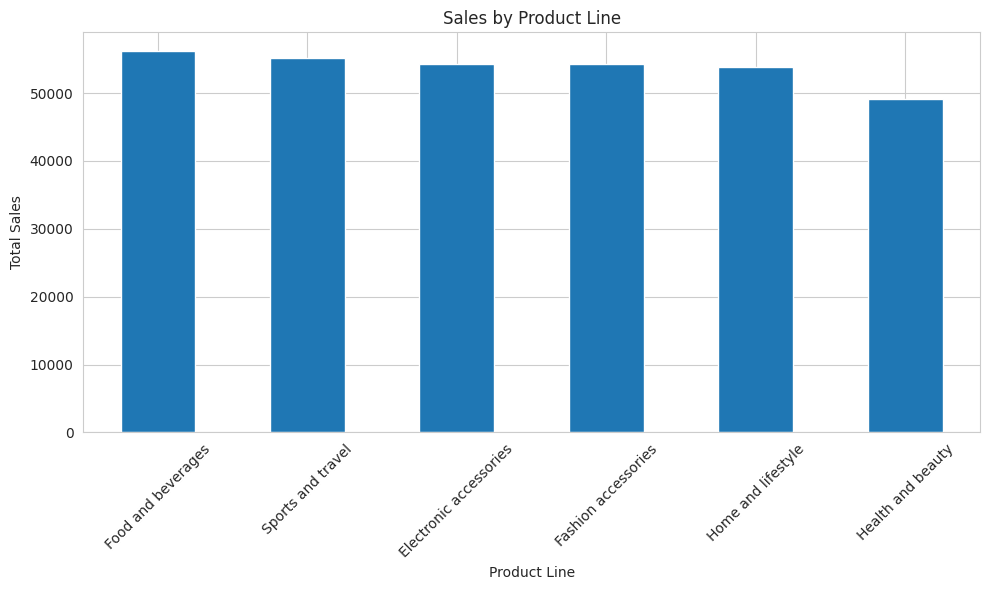

In [17]:
plt.figure(figsize=(10, 6))

product_sales.plot(kind="bar")

plt.title("Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Product Line Analysis

The product line analysis helps identify which categories generate the
highest total sales. This can help supermarkets understand product
category performance.

In [18]:
branch_sales = df.groupby("Branch")["Sales"].sum().sort_values(ascending=False)

print(branch_sales)

Branch
Giza     110568.7065
Alex     106200.3705
Cairo    106197.6720
Name: Sales, dtype: float64


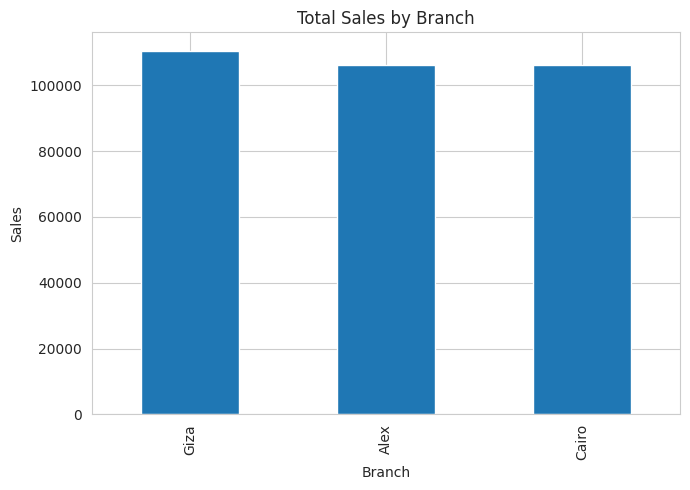

In [19]:
plt.figure(figsize=(7, 5))

branch_sales.plot(kind="bar")

plt.title("Total Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [20]:
city_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False)

print(city_sales)

City
Naypyitaw    110568.7065
Yangon       106200.3705
Mandalay     106197.6720
Name: Sales, dtype: float64


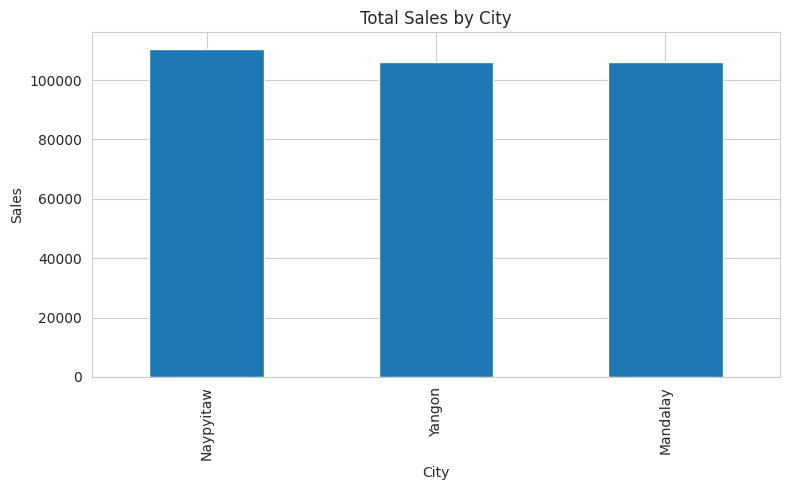

In [21]:
plt.figure(figsize=(8, 5))

city_sales.plot(kind="bar")

plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [22]:
payment_counts = df["Payment"].value_counts()

print(payment_counts)

Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64


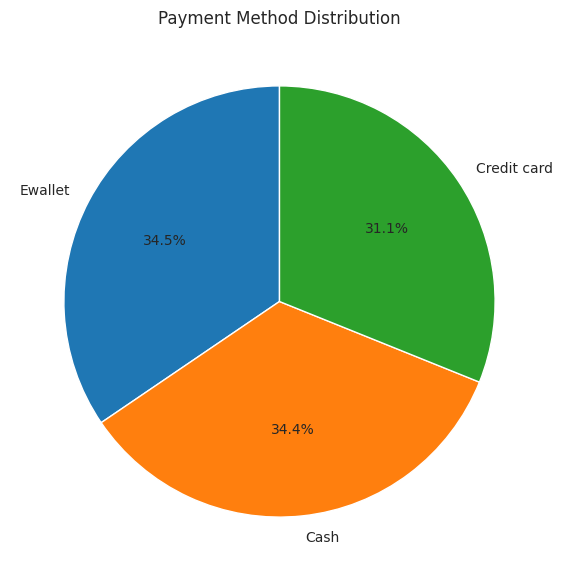

In [23]:
plt.figure(figsize=(7, 7))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Method Distribution")
plt.show()

In [24]:
gender_counts = df["Gender"].value_counts()

print(gender_counts)

Gender
Female    571
Male      429
Name: count, dtype: int64


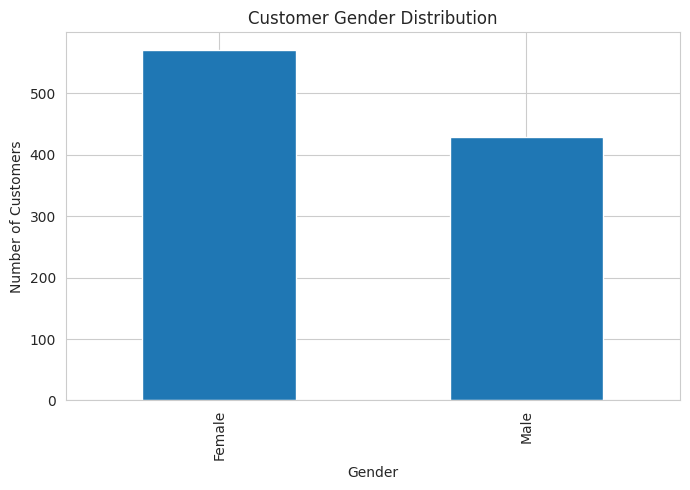

In [25]:
plt.figure(figsize=(7, 5))

gender_counts.plot(kind="bar")

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [26]:
quantity_by_product = df.groupby("Product line")["Quantity"].sum().sort_values(ascending=False)

print(quantity_by_product)

Product line
Electronic accessories    971
Food and beverages        952
Sports and travel         920
Home and lifestyle        911
Fashion accessories       902
Health and beauty         854
Name: Quantity, dtype: int64


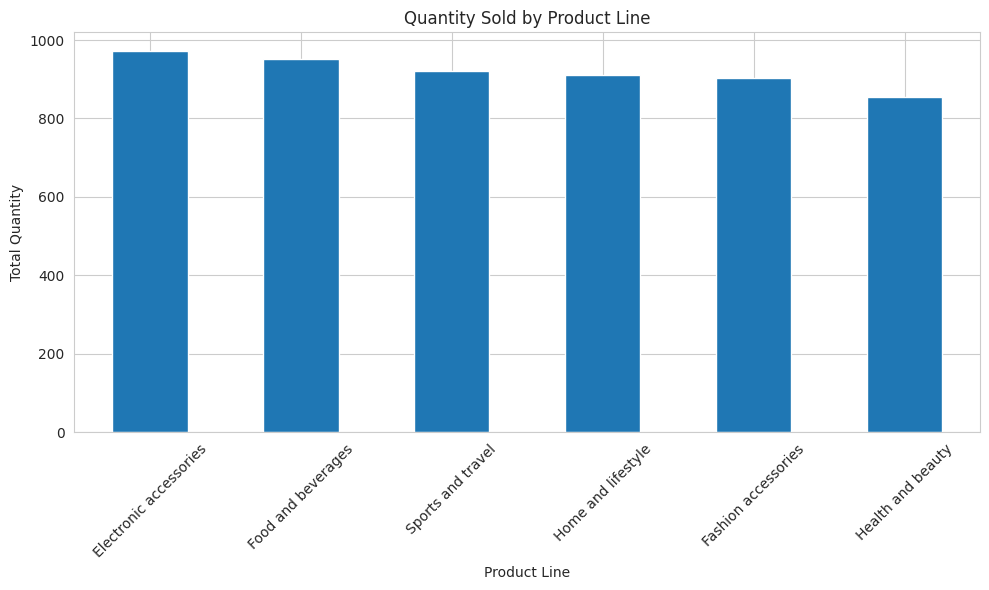

In [27]:
plt.figure(figsize=(10, 6))

quantity_by_product.plot(kind="bar")

plt.title("Quantity Sold by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [28]:
average_rating = df["Rating"].mean()

print("Average Customer Rating:", round(average_rating, 2))

Average Customer Rating: 6.97


In [29]:
rating_by_product = df.groupby("Product line")["Rating"].mean().sort_values(ascending=False)

print(rating_by_product)

Product line
Food and beverages        7.113218
Fashion accessories       7.029213
Health and beauty         7.003289
Electronic accessories    6.924706
Sports and travel         6.916265
Home and lifestyle        6.837500
Name: Rating, dtype: float64


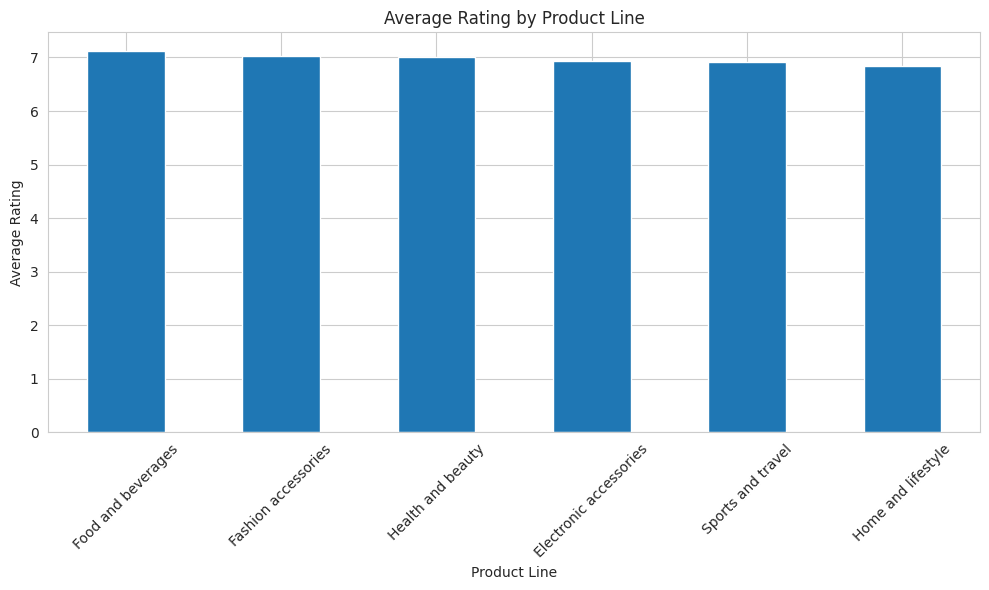

In [30]:
plt.figure(figsize=(10, 6))

rating_by_product.plot(kind="bar")

plt.title("Average Rating by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [31]:
income_by_product = df.groupby("Product line")["gross income"].sum().sort_values(ascending=False)

print(income_by_product)

Product line
Food and beverages        2673.5640
Sports and travel         2624.8965
Electronic accessories    2587.5015
Fashion accessories       2585.9950
Home and lifestyle        2564.8530
Health and beauty         2342.5590
Name: gross income, dtype: float64


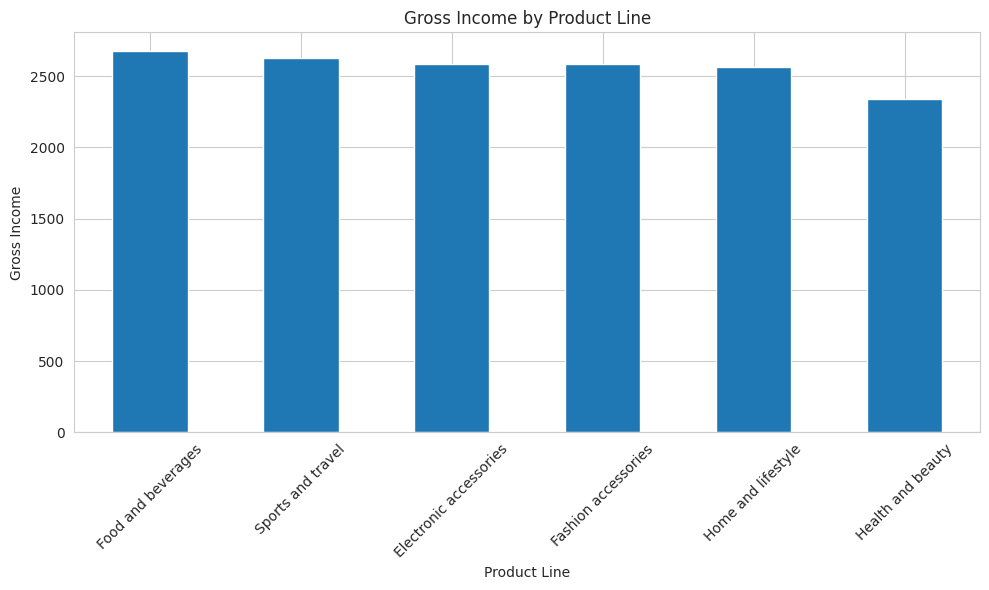

In [32]:
plt.figure(figsize=(10, 6))

income_by_product.plot(kind="bar")

plt.title("Gross Income by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Gross Income")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

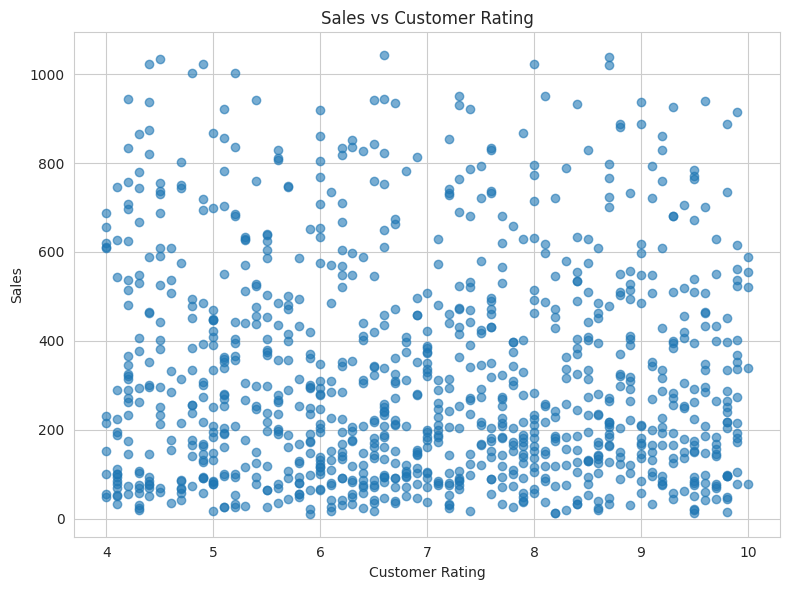

In [33]:
plt.figure(figsize=(8, 6))

plt.scatter(df["Rating"], df["Sales"], alpha=0.6)

plt.title("Sales vs Customer Rating")
plt.xlabel("Customer Rating")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

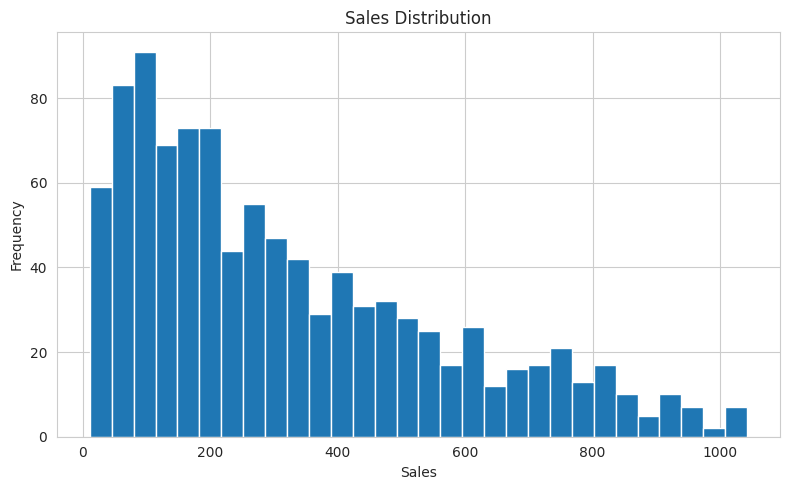

In [34]:
plt.figure(figsize=(8, 5))

plt.hist(df["Sales"], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

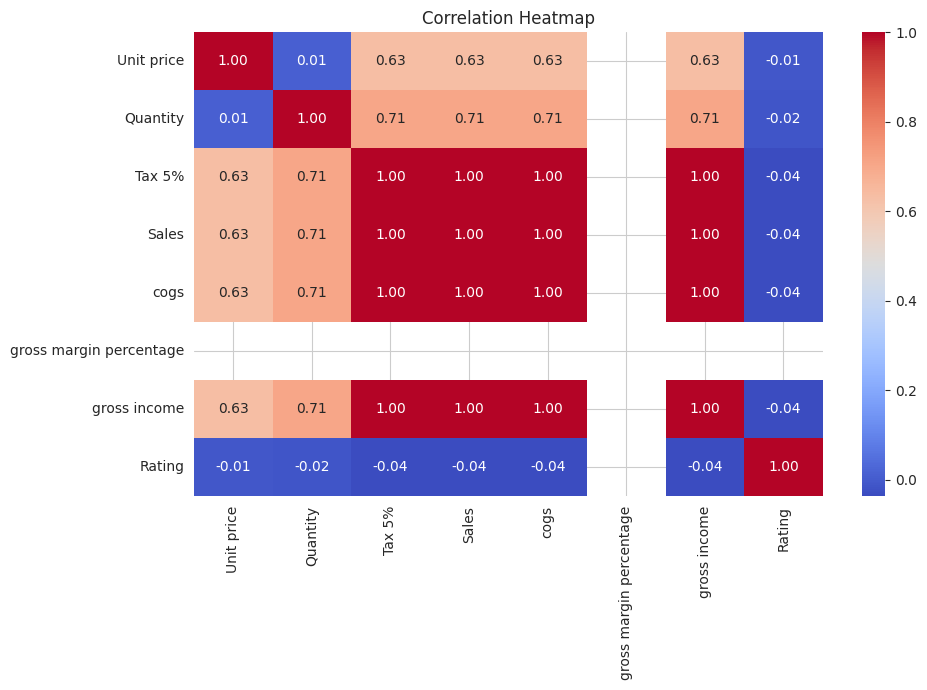

In [35]:
numeric_columns = [
    "Unit price",
    "Quantity",
    "Tax 5%",
    "Sales",
    "cogs",
    "gross margin percentage",
    "gross income",
    "Rating"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [36]:
top_sales = df.nlargest(10, "Sales")

top_sales[[
    "Invoice ID",
    "Branch",
    "City",
    "Product line",
    "Quantity",
    "Sales",
    "Payment"
]]

,Invoice ID,Branch,City,Product line,Quantity,Sales,Payment
350,860-79-0874,Giza,Naypyitaw,Fashion accessories,10,1042.650,Credit card
167,687-47-8271,Alex,Yangon,Fashion accessories,10,1039.290,Credit card
557,283-26-5248,Giza,Naypyitaw,Food and beverages,10,1034.460,Ewallet
699,751-41-9720,Giza,Naypyitaw,Home and lifestyle,10,1023.750,Ewallet
996,303-96-2227,Cairo,Mandalay,Home and lifestyle,10,1022.490,Ewallet
792,744-16-7898,Cairo,Mandalay,Home and lifestyle,10,1022.385,Credit card
422,271-88-8734,Giza,Naypyitaw,Fashion accessories,10,1020.705,Credit card
166,234-65-2137,Giza,Naypyitaw,Home and lifestyle,10,1003.590,Cash
357,554-42-2417,Giza,Naypyitaw,Sports and travel,10,1002.120,Cash
429,325-77-6186,Alex,Yangon,Home and lifestyle,10,951.825,Ewallet


# Key Findings

1. The dataset contains 1,000 supermarket transactions across different branches and cities.

2. Sales performance varies across product lines, allowing identification of the
   categories generating higher revenue.

3. Branch-level analysis shows differences in sales performance between branches.

4. Different payment methods are used by customers, with some methods being more
   frequently used than others.

5. Customer ratings provide information about customer satisfaction across product lines.

6. Gross income analysis helps identify product categories contributing more to
   overall profitability.

7. The correlation analysis shows relationships between sales, quantity, unit price,
   gross income, and customer ratings.

8. Visualizations make it easier to identify sales patterns and customer behavior.

# Conclusion

The SuperMarket Analysis project demonstrates how Python-based data analysis
can be used to understand supermarket sales and customer behavior.

The analysis examined sales, product lines, branches, cities, payment methods,
customer types, ratings, quantity, and gross income. Various visualizations
were created to make the patterns easier to understand.

This project provided practical experience with data cleaning, exploratory
data analysis, statistical analysis, visualization, and interpretation of
real-world business data.